In [11]:
import wandb
import matplotlib.pyplot as plt
import pandas as pd

In [9]:


ENTITY = "volverman22-universidad-aut-noma-de-madrid"
PROJECT = "gpt2-fineweb-pretraining"
RUN_NAME = "New_run_fix_issues"



In [15]:


api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")

run = next(r for r in runs if r.name == RUN_NAME)

# Descarga todo el historial de métricas del run
history = pd.DataFrame(
    run.scan_history(keys=["_step", "train/loss", "train/minibatch_loss", "validation/loss"])
)

def plot_metric(metric, y_max=10, log_scale=False):
    data = history.dropna(subset=["_step", metric])

    plt.figure(figsize=(10, 5))
    plt.plot(data["_step"], data[metric], label=RUN_NAME)
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(f"{metric} — {RUN_NAME}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if log_scale:
        plt.yscale("log")       # Escala logarítmica
    else:
        plt.ylim(0, y_max)      # Rango manual: 0–10

    plt.show()

# Gráficos con rango manual
#plot_metric("train/loss", y_max=10)
#plot_metric("train/minibatch_loss", y_max=10)

# O, si prefieres escala logarítmica:


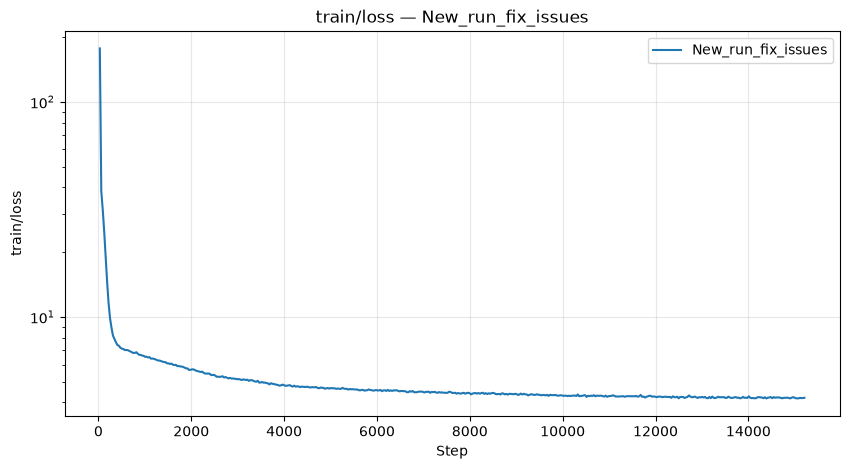

In [16]:
plot_metric("train/loss", log_scale=True)

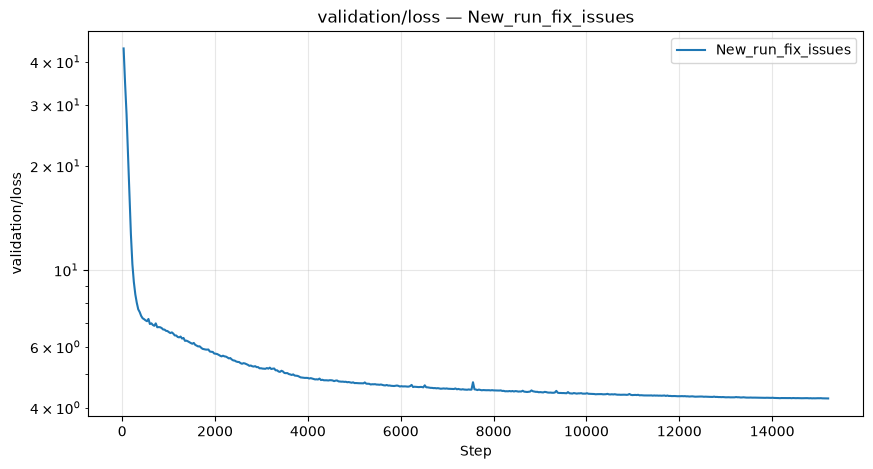

In [18]:

plot_metric("validation/loss", log_scale=True)

In [ ]:
plot_metric("train/loss", log_scale=True)
plot_metric("train/minibatch_loss", log_scale=True)